Checking for missing values:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


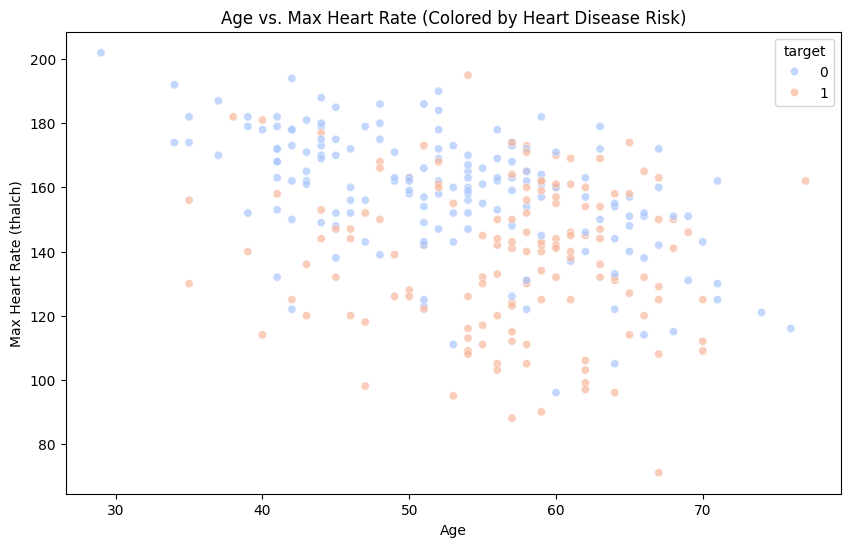

/var/folders/1p/g0qx34y54kj2x8hd2616kjym0000gn/T/ipykernel_35055/3216407395.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


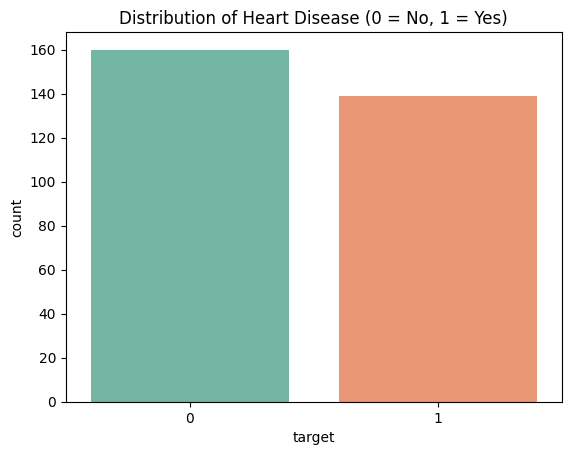

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

df = pd.read_csv('heart_disease_uci.csv')

print("Checking for missing values:")
print(df.isnull().sum())

df = df.drop(columns=['id', 'dataset'])

df = df.dropna()

df['target'] = (df['num'] > 0).astype(int)
df = df.drop(columns=['num'])

df = pd.get_dummies(df, drop_first=True)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='thalch', hue='target', data=df, palette='coolwarm', alpha=0.7)
plt.title("Age vs. Max Heart Rate (Colored by Heart Disease Risk)")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate (thalch)")
plt.show()

sns.countplot(x='target', data=df, palette='Set2')
plt.title("Distribution of Heart Disease (0 = No, 1 = Yes)")
plt.show()

Model Accuracy: 81.67%



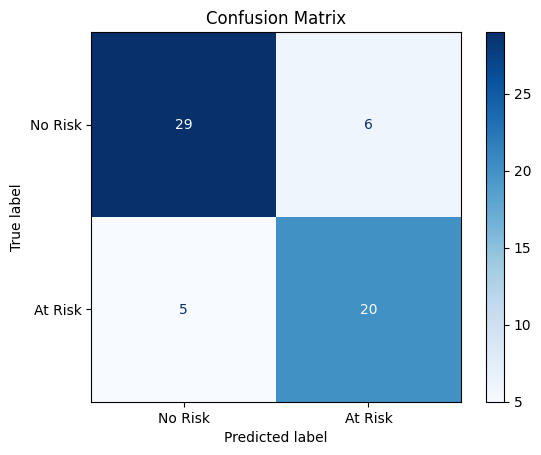

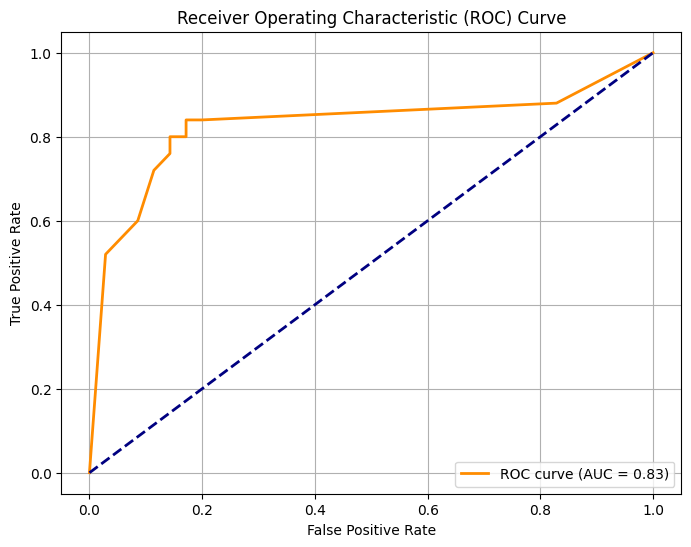

/var/folders/1p/g0qx34y54kj2x8hd2616kjym0000gn/T/ipykernel_35055/616950095.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


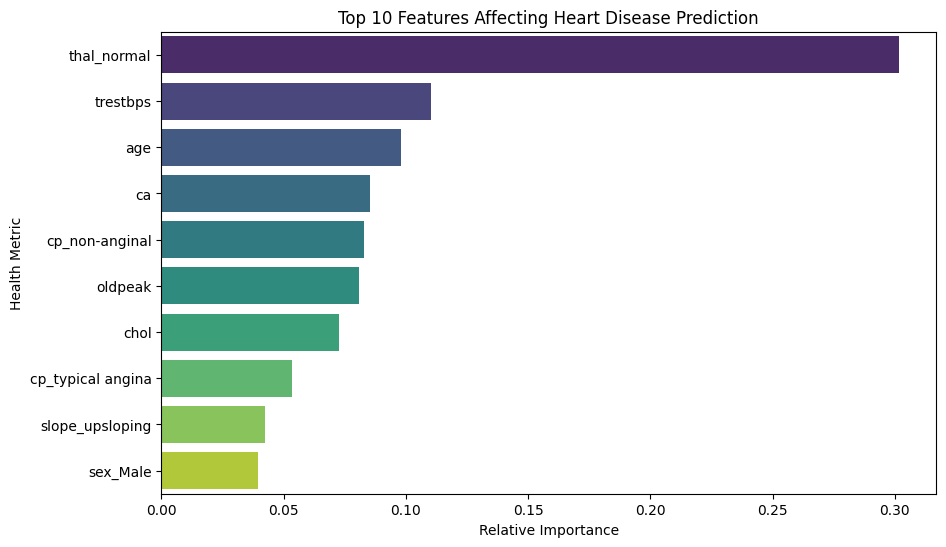

In [6]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(random_state=42, max_depth=5)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Risk", "At Risk"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, probabilities)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title("Top 10 Features Affecting Heart Disease Prediction")
plt.xlabel("Relative Importance")
plt.ylabel("Health Metric")
plt.show()